In [57]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV

import shap

In [58]:
df_lt = pd.read_csv('../../data/processed/featured_lt-vehicle-loan_train.csv')

In [59]:
lt_features = [
    "log_loan_amount",
    "log_installment",
    "log_delinquency",
    "log_inquiries",
    "log_credit_history_length",
    "credit_score_norm",
    "ltv_norm"
]

In [60]:
X = df_lt[lt_features]
y = df_lt["target"]

In [61]:
X.columns

Index(['log_loan_amount', 'log_installment', 'log_delinquency',
       'log_inquiries', 'log_credit_history_length', 'credit_score_norm',
       'ltv_norm'],
      dtype='object')

In [62]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
y_train.value_counts(normalize=True)

target
0    0.782928
1    0.217072
Name: proportion, dtype: float64

In [64]:
y_test.value_counts(normalize=True)

target
0    0.782934
1    0.217066
Name: proportion, dtype: float64

# Logistic Modeling

In [65]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [67]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [68]:
log_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", log_accuracy)

Accuracy: 0.5438442237996183


In [69]:
log_auc = roc_auc_score(y_test, y_prob)
print("ROC Accuracy:", log_auc)

ROC Accuracy: 0.5966034180851673


In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.52      0.64     36509
           1       0.26      0.62      0.37     10122

    accuracy                           0.54     46631
   macro avg       0.55      0.57      0.51     46631
weighted avg       0.71      0.54      0.58     46631



In [71]:
print(confusion_matrix(y_test, y_pred))

[[19111 17398]
 [ 3873  6249]]


In [72]:
# ~4k bad borrowers missed
# Adjust Decision Threshold from current value of 0.5
for t in [0.3, 0.4, 0.5]:
    y_pred_t = (y_prob > t).astype(int)
    print(confusion_matrix(y_test, y_pred_t))

[[ 1401 35108]
 [  184  9938]]
[[ 6525 29984]
 [  961  9161]]
[[19111 17398]
 [ 3873  6249]]


In [73]:
# Consider balanced threshold of 0.4
y_pred_final = (y_prob > 0.4).astype(int)

In [74]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.87      0.18      0.30     36509
           1       0.23      0.91      0.37     10122

    accuracy                           0.34     46631
   macro avg       0.55      0.54      0.33     46631
weighted avg       0.73      0.34      0.31     46631



In [75]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

# Positive values increases default risk
print(coeff_df)

                     Feature  Coefficient
6                   ltv_norm     0.204708
0            log_loan_amount     0.134434
2            log_delinquency     0.117011
3              log_inquiries     0.096878
1            log_installment     0.039693
4  log_credit_history_length    -0.083486
5          credit_score_norm    -0.190026


In [76]:
coeff_df.tail(5)

,Feature,Coefficient
2,log_delinquency,0.117011
3,log_inquiries,0.096878
1,log_installment,0.039693
4,log_credit_history_length,-0.083486
5,credit_score_norm,-0.190026


In [77]:
joblib.dump(log_model, "../../models/lt_logistic_model.pkl")

['../../models/lt_logistic_model.pkl']

# Gradient Boosting Modeling

In [78]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [79]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [80]:
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [81]:
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
y_pred_gb = (y_prob > 0.4).astype(int)

In [82]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.3363856661877292


In [83]:
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)
print("Gradient Boosting ROC-AUC:", roc_auc_gb)

Gradient Boosting ROC-AUC: 0.6186038100383895


In [84]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.87      0.18      0.30     36509
           1       0.23      0.91      0.37     10122

    accuracy                           0.34     46631
   macro avg       0.55      0.54      0.33     46631
weighted avg       0.73      0.34      0.31     46631



In [85]:
print(confusion_matrix(y_test, y_pred_gb))

[[ 6525 29984]
 [  961  9161]]


In [86]:
# Feature Importance Score
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                     feature  importance
5          credit_score_norm    0.304526
6                   ltv_norm    0.277311
0            log_loan_amount    0.203262
4  log_credit_history_length    0.067409
3              log_inquiries    0.060958
1            log_installment    0.051076
2            log_delinquency    0.035458


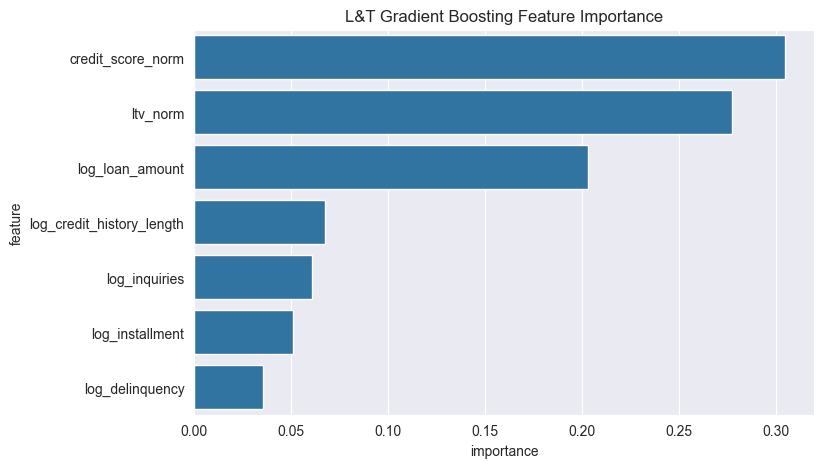

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance.head(10)
)

plt.title("L&T Gradient Boosting Feature Importance")

plt.savefig("../../output/plots/training/lt/gb_feature_importance.png")

plt.show()
plt.close()

In [88]:
# Using test data and true labels
r = permutation_importance(
    gb_model, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1, scoring="roc_auc"
)

perm_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": r["importances_mean"],
    "importance_std": r["importances_std"]
}).sort_values("importance_mean", ascending=False)

print(perm_imp.head(20))

                     feature  importance_mean  importance_std
5          credit_score_norm         0.046816        0.001631
6                   ltv_norm         0.040378        0.001703
0            log_loan_amount         0.014785        0.000955
4  log_credit_history_length         0.006592        0.000754
2            log_delinquency         0.005067        0.000780
3              log_inquiries         0.004701        0.000482
1            log_installment         0.004545        0.000560


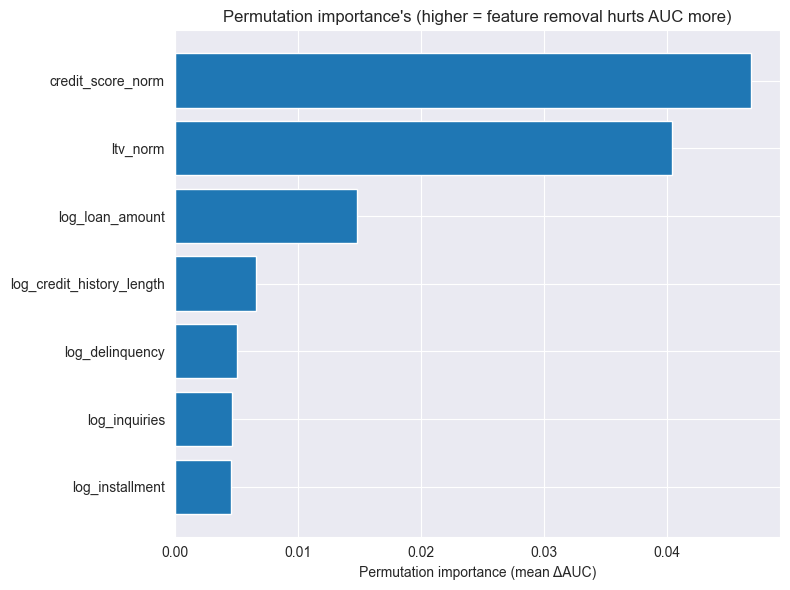

In [89]:
plt.figure(figsize=(8,6))
plt.barh(perm_imp["feature"].head(20)[::-1], perm_imp["importance_mean"].head(20)[::-1])
plt.xlabel("Permutation importance (mean ΔAUC)")
plt.title("Permutation importance's (higher = feature removal hurts AUC more)")
plt.tight_layout()
plt.savefig("../../output/plots/training/lt/perm_importance.png")
plt.show()
plt.close()

In [90]:
joblib.dump(gb_model, "../../models/lc_gradient_boosting_model.pkl")

['../../models/lc_gradient_boosting_model.pkl']

# Model Comparison

In [91]:
# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = roc_auc_score(y_test, y_prob)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)


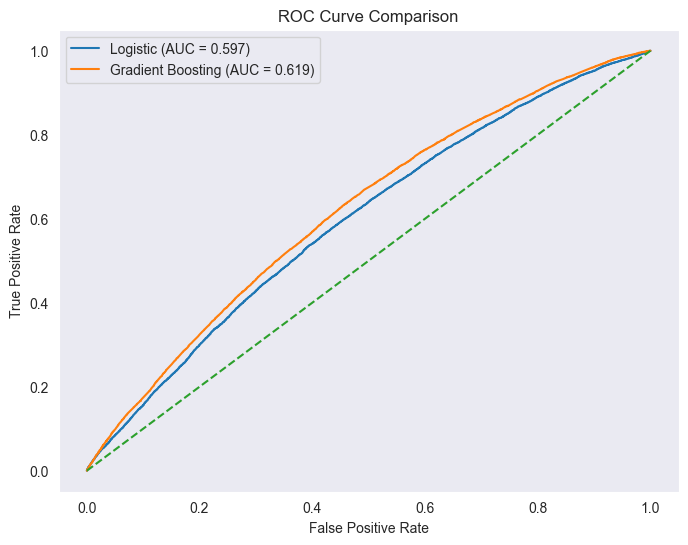

In [92]:
# ROC Curve Comparison
# ROC curve measures model discrimination.
# curve closer to top-left → better model

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.savefig("../../output/plots/training/lt/model_roc_comparison.png")
plt.show()
plt.close()

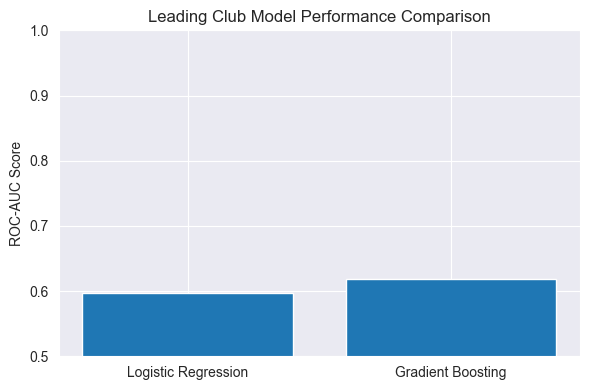

In [93]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosting"],
    "ROC_AUC": [auc_log, auc_gb]
})

plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["ROC_AUC"])

plt.ylabel("ROC-AUC Score")
plt.title("Leading Club Model Performance Comparison")
plt.ylim(0.5,1)

plt.tight_layout()
plt.savefig("../../output/plots/training/lt/model_comparison_auc.png")
plt.show()
plt.close()

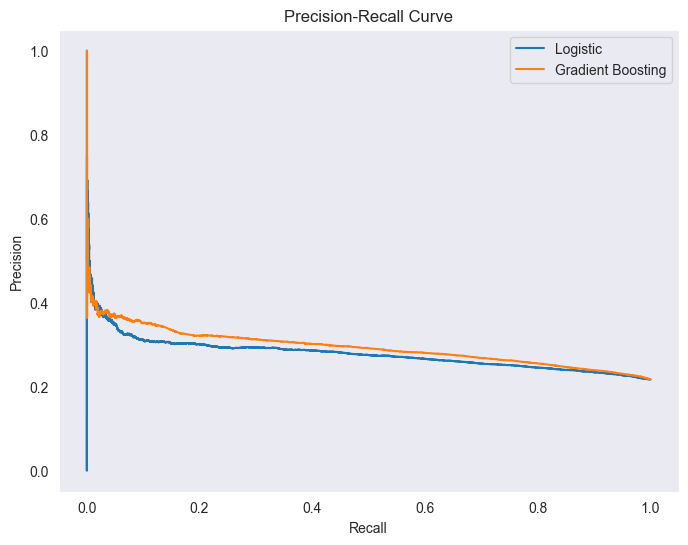

In [94]:
# Precision–Recall Curve
# PR curves are important because default datasets are imbalanced
# higher curve → better detection of defaults

# Logistic
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob)

# Gradient Boosting
precision_gb, recall_gb, _ = precision_recall_curve(y_test, y_prob_gb)
plt.figure(figsize=(8,6))
plt.plot(recall_log, precision_log, label="Logistic")
plt.plot(recall_gb, precision_gb, label="Gradient Boosting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.savefig("../../output/plots/training/lt/model_pr_curve.png")
plt.show()
plt.close()

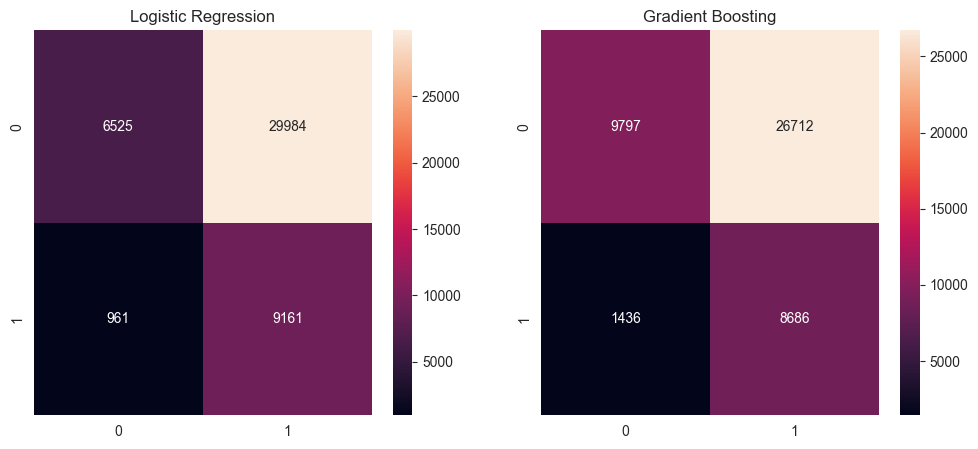

In [95]:
# Predictions
y_pred_log = (y_prob > 0.4).astype(int)
y_pred_gb = (y_prob_gb > 0.4).astype(int)

cm_log = confusion_matrix(y_test, y_pred_log)
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_log, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(cm_gb, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Gradient Boosting")
plt.savefig("../../output/plots/training/lt/model_confusion_matrix_compare.png")
plt.show()
plt.close()

In [96]:
brier_log = brier_score_loss(y_test, y_prob)
brier_gb = brier_score_loss(y_test, y_prob_gb)

print("Logistic Brier:", brier_log)
print("GB Brier:", brier_gb)

Logistic Brier: 0.24288582266238729
GB Brier: 0.23886045530473568


In [97]:
gb_calibrated = CalibratedClassifierCV(
    gb_model,
    method="sigmoid",   # Platt Scaling
    cv=5
)

gb_calibrated.fit(X_train, y_train)

# New calibrated probabilities
y_prob_gb_cal = gb_calibrated.predict_proba(X_test)[:, 1]

In [98]:
brier_gb_cal = brier_score_loss(y_test, y_prob_gb_cal)
print("Calibrated GB Brier:", brier_gb_cal)

Calibrated GB Brier: 0.16496380863892943


In [99]:
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_prob_gb_cal, n_bins=10
)

In [100]:
# Gradient Boosting (calibrated with Platt Scaling)
y_prob_final = y_prob_gb_cal
y_pred_final = (y_prob_final > 0.4).astype(int)

In [101]:
X.columns

Index(['log_loan_amount', 'log_installment', 'log_delinquency',
       'log_inquiries', 'log_credit_history_length', 'credit_score_norm',
       'ltv_norm'],
      dtype='object')

In [102]:
joblib.dump({
    "model": gb_calibrated,
    "features": X.columns.tolist(),
    "threshold": 0.4
}, "../../models/lt_calibrated_gradient_boosting_model.pkl")

['../../models/lt_calibrated_gradient_boosting_model.pkl']

# Model Explainability (SHAP Analysis)

In [103]:
# Initialize SHAP
explainer = shap.Explainer(gb_model)

In [104]:
# Compute SHAP Values on the validation dataset
shap_values = explainer(X_test)

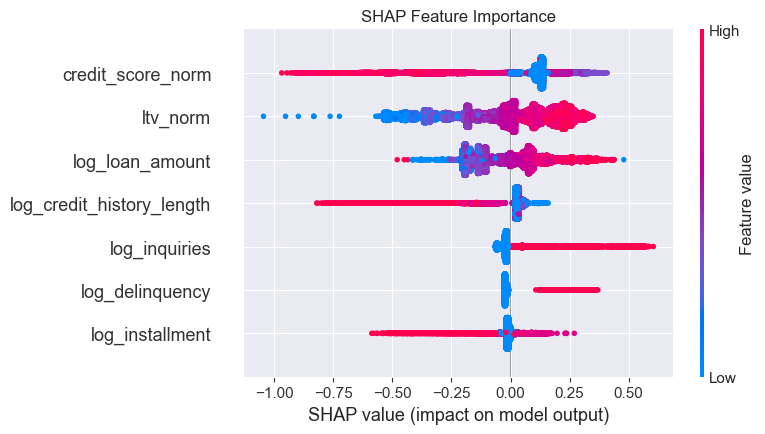

In [105]:
# SHAP Summary Plot
# Features at top means better impact on default prediction
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance")
plt.savefig("../../output/plots/training/lt/shap_summary.png")
plt.show()
plt.close()

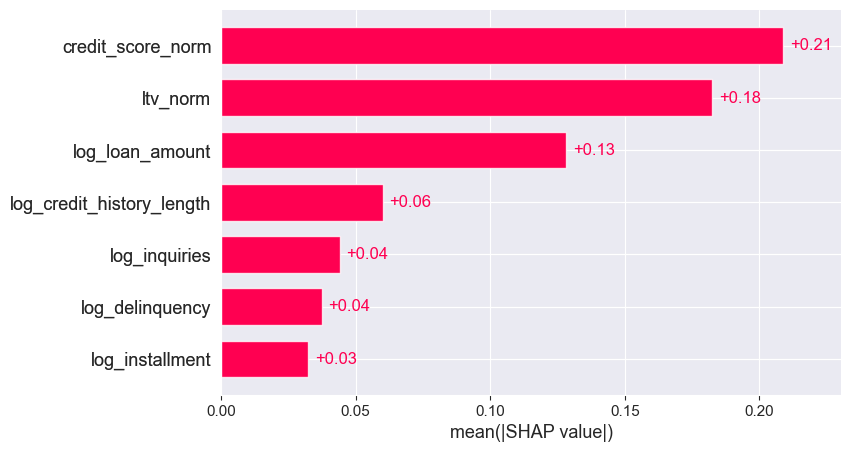

In [106]:
# SHAP Bar Plot
# Shows average feature importance
plt.figure()

shap.plots.bar(shap_values, show=False)

plt.savefig("../../output/plots/training/lt/shap_bar_plot.png")
plt.show()
plt.close()

SHAP Dependence Plot
Shows how a feature influences predictions.

<Figure size 640x480 with 0 Axes>

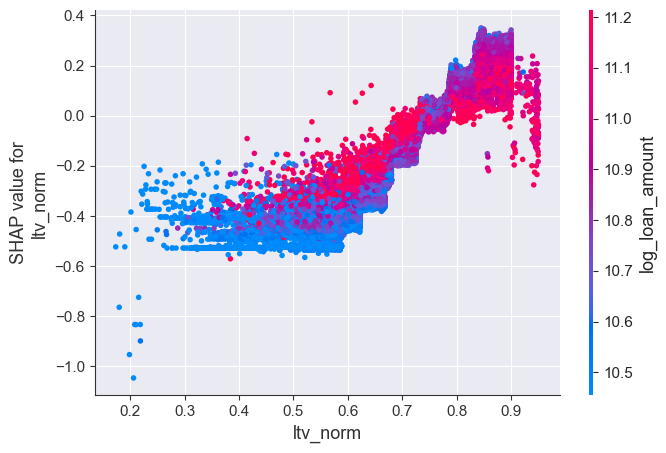

In [107]:
plt.figure()
shap.dependence_plot(
    "ltv_norm",
    shap_values.values,
    X_test,
    show=False
)

plt.savefig("../../output/plots/training/lt/shap_ltv_norm_dependence.png")
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

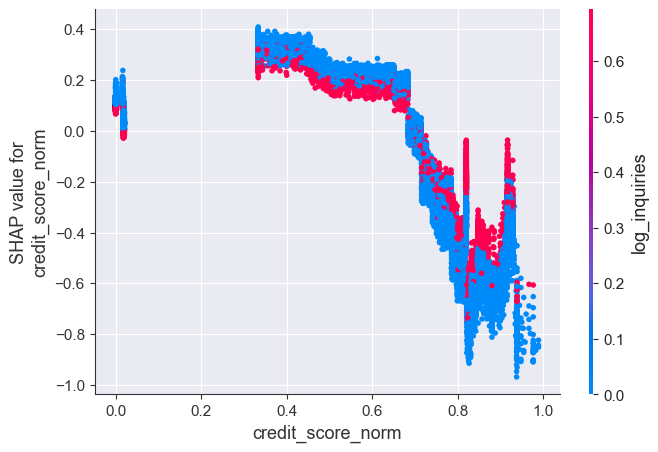

In [108]:
plt.figure()
shap.dependence_plot(
    "credit_score_norm",
    shap_values.values,
    X_test,
    show=False
)

plt.savefig("../../output/plots/training/lt/shap_credit_score_norm_dependence.png")
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

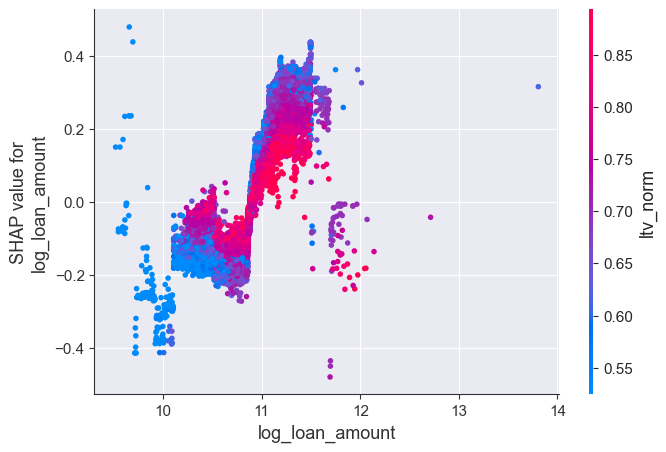

In [109]:
plt.figure()
shap.dependence_plot(
    "log_loan_amount",
    shap_values.values,
    X_test,
    show=False
)

plt.savefig("../../output/plots/training/lt/shap_loan_amount_dependence.png")
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

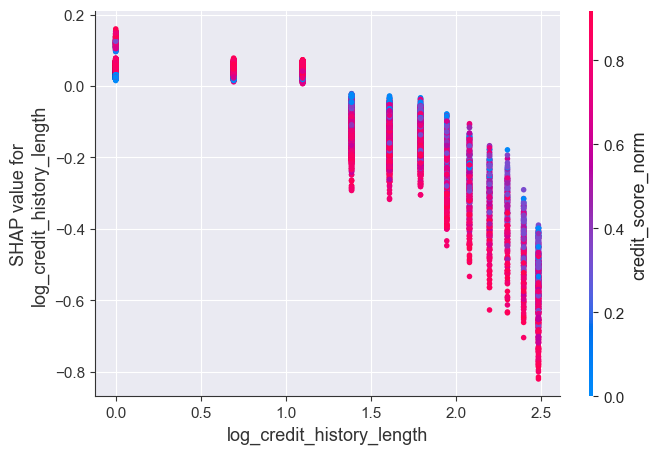

In [110]:
plt.figure()
shap.dependence_plot(
    "log_credit_history_length",
    shap_values.values,
    X_test,
    show=False
)

plt.savefig("../../output/plots/training/lt/shap_log_credit_history_dependence.png")
plt.show()
plt.close()